# 02 — GRU Baseline
### Standard GRU classifier — Baseline 2
> Run 00_Data_Preparation.ipynb first.

In [5]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import f1_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')

✅ Device: cpu


In [6]:
with open('prepared_data.pkl','rb') as f: d = pickle.load(f)
with open('encoder.pkl','rb') as f: encoder = pickle.load(f)

X_train = torch.FloatTensor(d['X_train_seq']).to(DEVICE)
X_test  = torch.FloatTensor(d['X_test_seq']).to(DEVICE)
y_train = torch.LongTensor(d['y_train_seq']).to(DEVICE)
y_test  = torch.LongTensor(d['y_test_seq']).to(DEVICE)

NUM_CLASSES  = d['num_classes']
NUM_FEATURES = d['num_features']

# ── CLASS WEIGHTS ─────────────────────────────────────────────────────
class_counts   = np.bincount(d['y_train_seq'])
class_weights  = 1.0 / class_counts
class_weights  = class_weights / class_weights.sum() * len(class_counts)
weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)
print(f'✅ Data loaded. Classes: {list(encoder.classes_)}')
print(f'   Class counts  : {class_counts}')
print(f'   Class weights : {class_weights.round(3)}')

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)

✅ Data loaded. Classes: ['Blade Blunt', 'Healthy', 'High Foot Pressure', 'Skip Stitches/Slip', 'Waveness']
   Class counts  : [  85 3951   87   85   84]
   Class weights : [1.247 0.027 1.218 1.247 1.262]


#### GRU Architecture

In [7]:
class GRUClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3):
        super().__init__()
        self.gru  = nn.GRU(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=dropout)
        self.bn   = nn.BatchNorm1d(hidden_size)
        self.fc1  = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(dropout)
        self.fc2  = nn.Linear(32, num_classes)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.bn(out[:, -1, :])
        out = self.drop(self.relu(self.fc1(out)))
        return self.fc2(out)

model = GRUClassifier(NUM_FEATURES, hidden_size=64, num_layers=2,
                      num_classes=NUM_CLASSES).to(DEVICE)
print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

GRUClassifier(
  (gru): GRU(66, 64, num_layers=2, batch_first=True, dropout=0.3)
  (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (drop): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=32, out_features=5, bias=True)
)
Parameters: 52,677


#### Train

Epoch   1 | Train: 1.5733 | Val: 1.6502
Epoch   2 | Train: 1.5378 | Val: 1.6498
Epoch   3 | Train: 1.5229 | Val: 1.6798
Epoch   4 | Train: 1.4630 | Val: 1.6945
Epoch   5 | Train: 1.4628 | Val: 1.7096
Epoch   6 | Train: 1.3888 | Val: 1.7566
Epoch   7 | Train: 1.3669 | Val: 1.7608
Epoch   8 | Train: 1.3238 | Val: 1.7961
Epoch   9 | Train: 1.3458 | Val: 1.8282
Epoch  10 | Train: 1.2607 | Val: 1.8614
Epoch  11 | Train: 1.2032 | Val: 1.9162
Epoch  12 | Train: 1.1367 | Val: 1.9148
Epoch  13 | Train: 1.1154 | Val: 1.9390
Epoch  14 | Train: 1.1198 | Val: 1.9507
Epoch  15 | Train: 1.1200 | Val: 1.9552
Epoch  16 | Train: 1.1115 | Val: 1.9439
Epoch  17 | Train: 1.1000 | Val: 1.9734
Epoch  18 | Train: 1.0962 | Val: 1.9922
Epoch  19 | Train: 1.1083 | Val: 2.0094
Epoch  20 | Train: 1.1197 | Val: 2.0005
Epoch  21 | Train: 1.1008 | Val: 2.0072
Early stopping at epoch 22


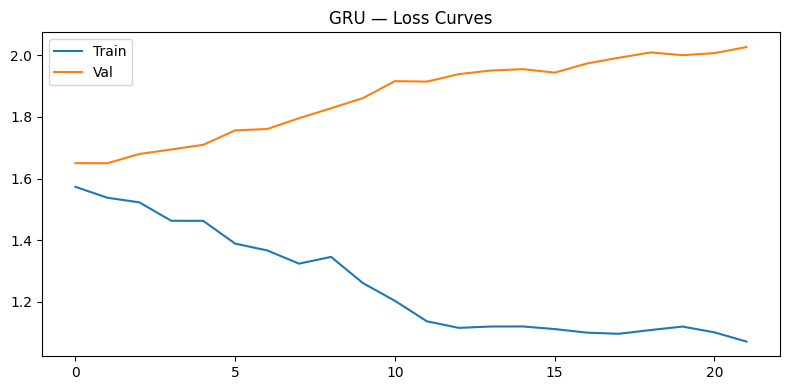

In [10]:
EPOCHS    = 25
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-3)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=8)

best_val_loss    = float('inf')
patience_counter = 0
PATIENCE         = 20
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        batch_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_test), y_test).item()
    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_gru.pt')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

    print(f'Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}')

plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.title('GRU — Loss Curves')
plt.legend()
plt.tight_layout()
plt.savefig('gru_loss.png', dpi=150)
plt.show()

#### Evaluate

GRU BASELINE RESULTS
Accuracy : 62.92%
F1 Score : 0.7201
RMSE     : 1.4218
MAE      : 0.7912

                    precision    recall  f1-score   support

       Blade Blunt       0.01      0.05      0.02        21
           Healthy       0.92      0.68      0.78       983
High Foot Pressure       0.02      0.05      0.03        22
Skip Stitches/Slip       0.00      0.00      0.00        21
          Waveness       0.01      0.10      0.02        21

          accuracy                           0.63      1068
         macro avg       0.19      0.17      0.17      1068
      weighted avg       0.85      0.63      0.72      1068



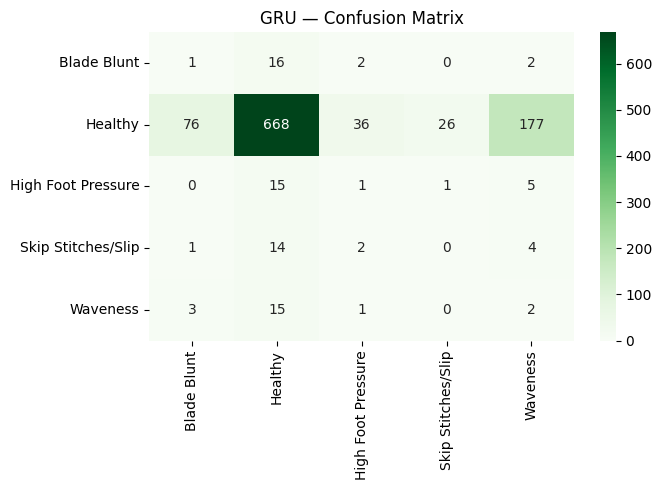

✅ Results saved to gru_results.pkl


In [9]:
model.load_state_dict(torch.load('best_gru.pt'))
model.eval()
with torch.no_grad():
    y_pred = np.argmax(torch.softmax(model(X_test),dim=1).cpu().numpy(), axis=1)
    y_true = y_test.cpu().numpy()

acc  = accuracy_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred, average='weighted')
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)

print('='*50)
print('GRU BASELINE RESULTS')
print('='*50)
print(f'Accuracy : {acc*100:.2f}%')
print(f'F1 Score : {f1:.4f}')
print(f'RMSE     : {rmse:.4f}')
print(f'MAE      : {mae:.4f}')
print()
print(classification_report(y_true, y_pred, target_names=encoder.classes_))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title('GRU — Confusion Matrix')
plt.tight_layout()
plt.savefig('gru_confusion.png', dpi=150)
plt.show()

gru_results = {'model':'GRU','accuracy':acc,'f1':f1,'rmse':rmse,'mae':mae}
with open('gru_results.pkl','wb') as f: pickle.dump(gru_results, f)
print('✅ Results saved to gru_results.pkl')